# 📰 Fake News Detection System
**International Islamic University, Islamabad**  
**Department:** Software Engineering  
**Course:** Artificial Intelligence  
**Submitted To:** Shakeel Ahmad  
**Group 12**

---

## Project Description
This project builds a **Fake News Detection** system using Natural Language Processing (NLP) techniques.  
We classify news articles as **FAKE** or **REAL** using:
- **TF-IDF** vectorization for text representation
- **Logistic Regression** for baseline classification
- **Random Forest** for ensemble classification

**Dataset:** [Fake and Real News Dataset — Kaggle](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset)  
**Dataset Files Used:** `Fake.csv` (~23,481 articles) and `True.csv` (~21,417 articles)

## 1. Import Libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLP
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

# ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

# Display
from IPython.display import display
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load & Prepare Real Dataset
We load the actual Kaggle Fake-and-Real-News dataset from the two CSV files.  
Make sure `Fake.csv` and `True.csv` are in the same folder as this notebook.

In [54]:
# ── Load the real Kaggle CSV files ──────────────────────────────────────────
fake = pd.read_csv('Fake.csv')
real = pd.read_csv('True.csv')

# Add label column  (0 = FAKE, 1 = REAL)
fake['label']      = 0
fake['label_name'] = 'FAKE'

real['label']      = 1
real['label_name'] = 'REAL'

# Combine both into one DataFrame and shuffle
df = pd.concat([fake, real], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Fake articles loaded : {len(fake)}")
print(f"Real articles loaded : {len(real)}")
print(f"Total dataset shape  : {df.shape}")
print(f"Columns              : {list(df.columns)}")
display(df.head(5))

Fake articles loaded : 23481
Real articles loaded : 21417
Total dataset shape  : (44898, 6)
Columns              : ['title', 'text', 'subject', 'date', 'label', 'label_name']


,title,text,subject,date,label,label_name
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,FAKE
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,REAL
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,REAL
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,FAKE
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,REAL


## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Overview — Shape, Columns, Types, Missing Values

In [55]:
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape            : {df.shape}")
print(f"Total Articles   : {len(df)}")
print(f"  → FAKE         : {len(df[df['label']==0])}")
print(f"  → REAL         : {len(df[df['label']==1])}")
print(f"\nColumn Data Types:")
print(df.dtypes)
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nSubject Categories:")
print(df['subject'].value_counts())

DATASET OVERVIEW
Shape            : (44898, 6)
Total Articles   : 44898
  → FAKE         : 23481
  → REAL         : 21417

Column Data Types:
title           str
text            str
subject         str
date            str
label         int64
label_name      str
dtype: object

Missing Values:
title         0
text          0
subject       0
date          0
label         0
label_name    0
dtype: int64

Subject Categories:
subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


### 3.2 Class Distribution (Fake vs Real)

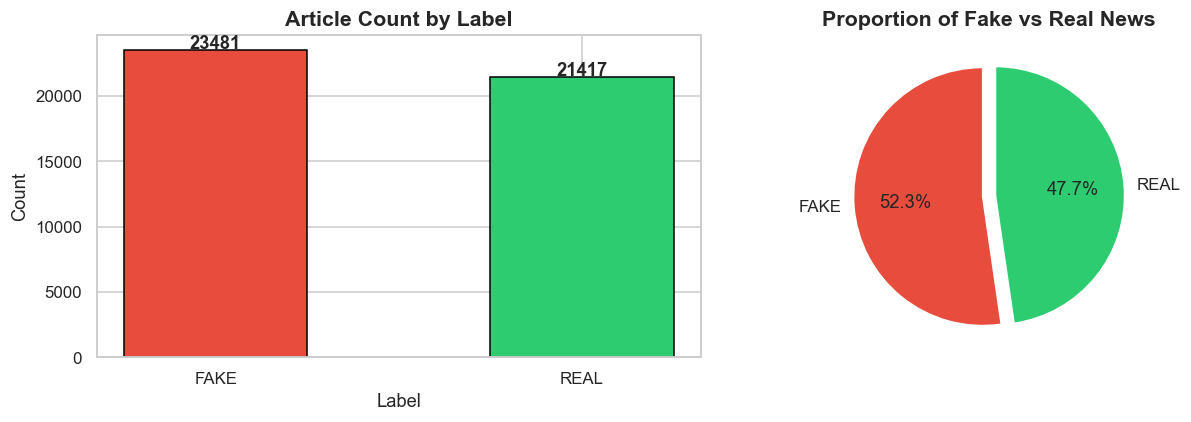

label_name
FAKE    23481
REAL    21417
Name: count, dtype: int64


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label_name'].value_counts()
# Ensure FAKE is red, REAL is green regardless of ordering
color_map = {'FAKE': '#E74C3C', 'REAL': '#2ECC71'}
colors = [color_map[label] for label in counts.index]

# Bar chart
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Article Count by Label', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 80, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Proportion of Fake vs Real News', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()
print(counts)

### 3.3 Statistical Summary — Mean, Median, Std of Text Length

In [57]:
df['text_length']  = df['text'].apply(len)
df['word_count']   = df['text'].apply(lambda x: len(str(x).split()))
df['title_length'] = df['title'].apply(len)

print("Statistical Summary — Text Features by Label")
print(df.groupby('label_name')[['text_length', 'word_count', 'title_length']].describe().round(2))

print("\nMean values by label:")
print(df.groupby('label_name')[['text_length', 'word_count', 'title_length']].mean().round(2))

Statistical Summary — Text Features by Label
           text_length                                                 \
                 count     mean      std  min     25%     50%     75%   
label_name                                                              
FAKE           23481.0  2547.40  2532.88  1.0  1433.0  2166.0  3032.0   
REAL           21417.0  2383.28  1684.84  1.0   914.0  2222.0  3237.0   

                    word_count          ...                title_length  \
                max      count    mean  ...    75%     max        count   
label_name                              ...                               
FAKE        51794.0    23481.0  423.20  ...  506.0  8135.0      23481.0   
REAL        29781.0    21417.0  385.64  ...  525.0  5172.0      21417.0   

                                                          
             mean    std   min   25%   50%    75%    max  
label_name                                                
FAKE        94.20  27.18   8.0  77.0

### 3.4 Text Length Distribution — Histograms & Boxplots

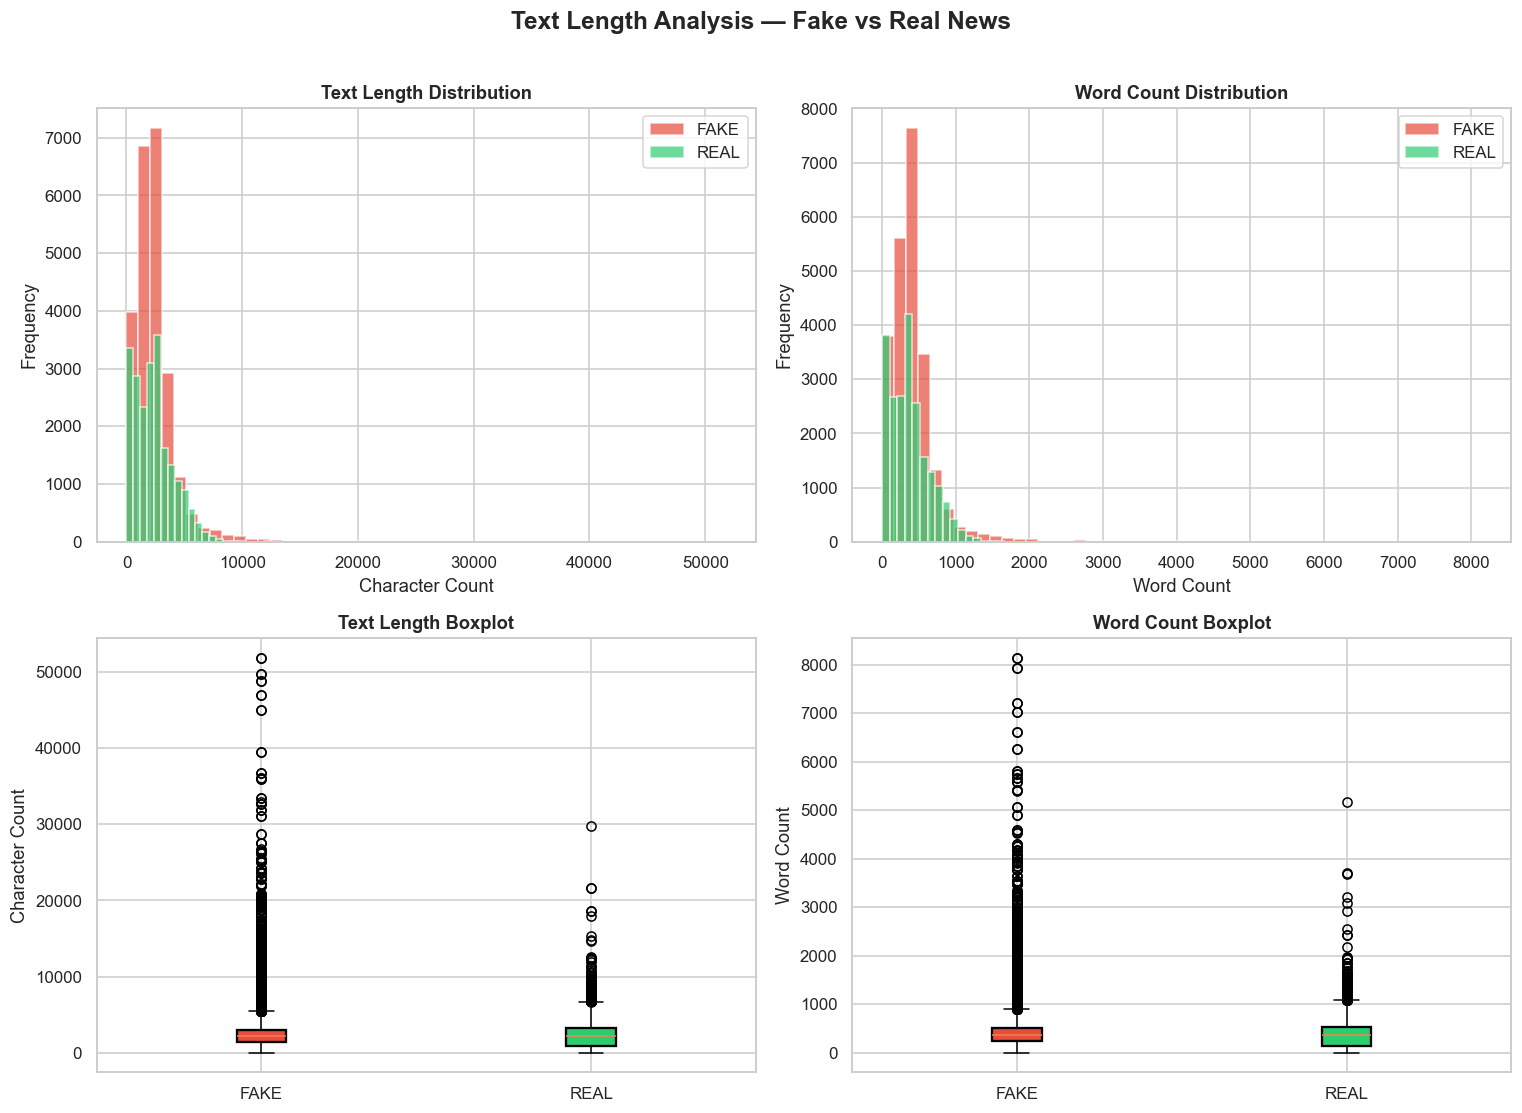

In [58]:
fake_df = df[df['label_name'] == 'FAKE']
real_df = df[df['label_name'] == 'REAL']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram — text length
axes[0,0].hist(fake_df['text_length'], bins=50, alpha=0.7, color='#E74C3C', label='FAKE')
axes[0,0].hist(real_df['text_length'], bins=50, alpha=0.7, color='#2ECC71', label='REAL')
axes[0,0].set_title('Text Length Distribution', fontweight='bold')
axes[0,0].set_xlabel('Character Count')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Histogram — word count
axes[0,1].hist(fake_df['word_count'], bins=50, alpha=0.7, color='#E74C3C', label='FAKE')
axes[0,1].hist(real_df['word_count'], bins=50, alpha=0.7, color='#2ECC71', label='REAL')
axes[0,1].set_title('Word Count Distribution', fontweight='bold')
axes[0,1].set_xlabel('Word Count')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()

# Boxplot — text length
bp1 = axes[1,0].boxplot([fake_df['text_length'], real_df['text_length']],
                         labels=['FAKE', 'REAL'], patch_artist=True,
                         boxprops=dict(linewidth=1.5))
for patch, color in zip(bp1['boxes'], ['#E74C3C', '#2ECC71']):
    patch.set_facecolor(color)
axes[1,0].set_title('Text Length Boxplot', fontweight='bold')
axes[1,0].set_ylabel('Character Count')

# Boxplot — word count
bp2 = axes[1,1].boxplot([fake_df['word_count'], real_df['word_count']],
                         labels=['FAKE', 'REAL'], patch_artist=True,
                         boxprops=dict(linewidth=1.5))
for patch, color in zip(bp2['boxes'], ['#E74C3C', '#2ECC71']):
    patch.set_facecolor(color)
axes[1,1].set_title('Word Count Boxplot', fontweight='bold')
axes[1,1].set_ylabel('Word Count')

plt.suptitle('Text Length Analysis — Fake vs Real News', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('text_length_analysis.png', bbox_inches='tight')
plt.show()

### 3.5 Outlier Detection — Articles with Unusually Long or Short Text

IQR Lower Bound : -262 words
IQR Upper Bound : 978 words
Total Outliers  : 1678
  → FAKE outliers: 1053
  → REAL outliers: 625


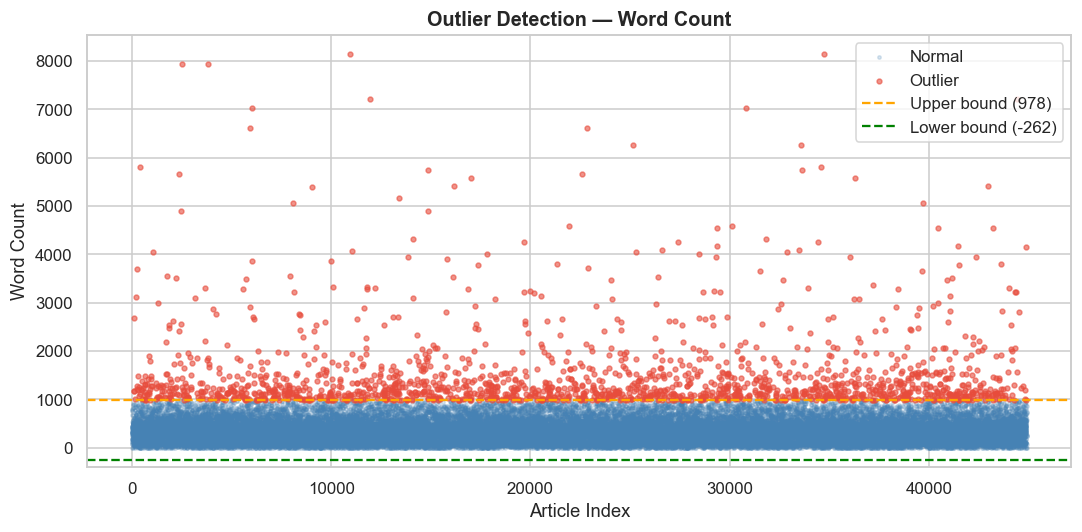

In [59]:
# Outlier detection using IQR method on word_count
Q1 = df['word_count'].quantile(0.25)
Q3 = df['word_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['word_count'] < lower_bound) | (df['word_count'] > upper_bound)]
print(f"IQR Lower Bound : {lower_bound:.0f} words")
print(f"IQR Upper Bound : {upper_bound:.0f} words")
print(f"Total Outliers  : {len(outliers)}")
print(f"  → FAKE outliers: {len(outliers[outliers['label']==0])}")
print(f"  → REAL outliers: {len(outliers[outliers['label']==1])}")

# Scatter plot to visualise outliers
fig, ax = plt.subplots(figsize=(10, 5))
normal = df[~df.index.isin(outliers.index)]
ax.scatter(normal.index, normal['word_count'], alpha=0.2, s=5, color='steelblue', label='Normal')
ax.scatter(outliers.index, outliers['word_count'], alpha=0.6, s=10, color='#E74C3C', label='Outlier')
ax.axhline(upper_bound, color='orange', linestyle='--', lw=1.5, label=f'Upper bound ({upper_bound:.0f})')
ax.axhline(lower_bound, color='green',  linestyle='--', lw=1.5, label=f'Lower bound ({lower_bound:.0f})')
ax.set_title('Outlier Detection — Word Count', fontweight='bold', fontsize=13)
ax.set_xlabel('Article Index')
ax.set_ylabel('Word Count')
ax.legend()
plt.tight_layout()
plt.savefig('outlier_detection.png', bbox_inches='tight')
plt.show()

### 3.6 Fake vs Real News Ratio

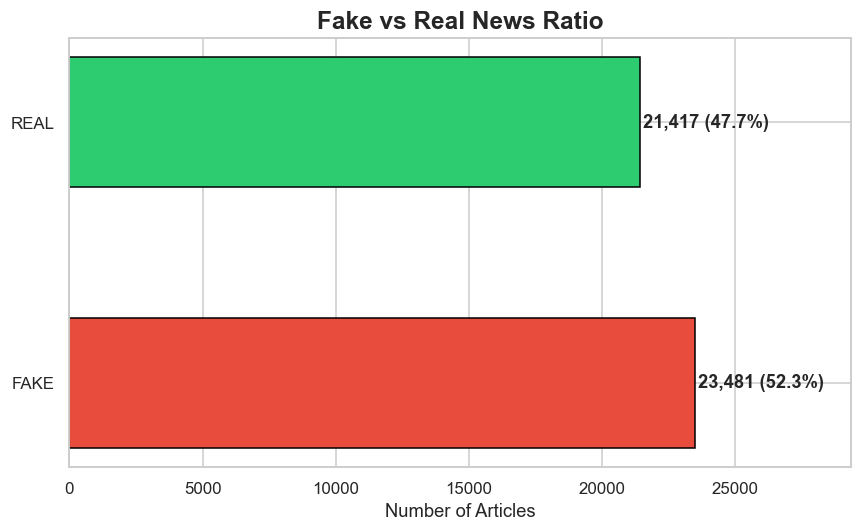

In [60]:
fig, ax = plt.subplots(figsize=(8, 5))

labels_list = ['FAKE', 'REAL']
values_list = [len(fake_df), len(real_df)]
colors_list = ['#E74C3C', '#2ECC71']
bars = ax.barh(labels_list, values_list, color=colors_list, edgecolor='black', height=0.5)

for bar, val in zip(bars, values_list):
    pct = val / len(df) * 100
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct:.1f}%)', va='center', fontweight='bold')

ax.set_title('Fake vs Real News Ratio', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Articles')
ax.set_xlim(0, max(values_list) * 1.25)
plt.tight_layout()
plt.savefig('fake_real_ratio.png', bbox_inches='tight')
plt.show()

### 3.7 Correlation Analysis — Numeric Features vs Label

Correlation Matrix:
              text_length  word_count  title_length   label
text_length        1.0000      0.9959        0.0321 -0.0377
word_count         0.9959      1.0000        0.0418 -0.0534
title_length       0.0321      0.0418        1.0000 -0.5812
label             -0.0377     -0.0534       -0.5812  1.0000


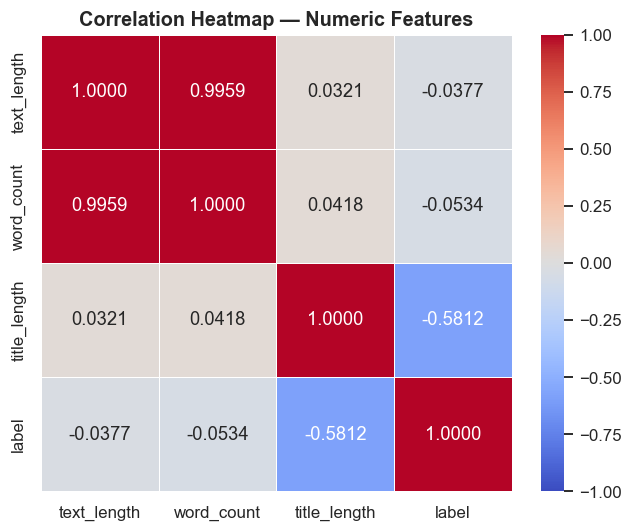


Correlation with Label (0=FAKE, 1=REAL):
title_length   -0.581159
word_count     -0.053405
text_length    -0.037747
Name: label, dtype: float64


In [61]:
# Correlation between numeric features and the label
corr_cols = ['text_length', 'word_count', 'title_length', 'label']
corr_matrix = df[corr_cols].corr()

print("Correlation Matrix:")
print(corr_matrix.round(4))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Numeric Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("\nCorrelation with Label (0=FAKE, 1=REAL):")
print(df[corr_cols].corr()['label'].drop('label').sort_values())

### 3.8 Word Cloud — Fake News vs Real News

Generating word clouds from real articles (this may take a moment)...


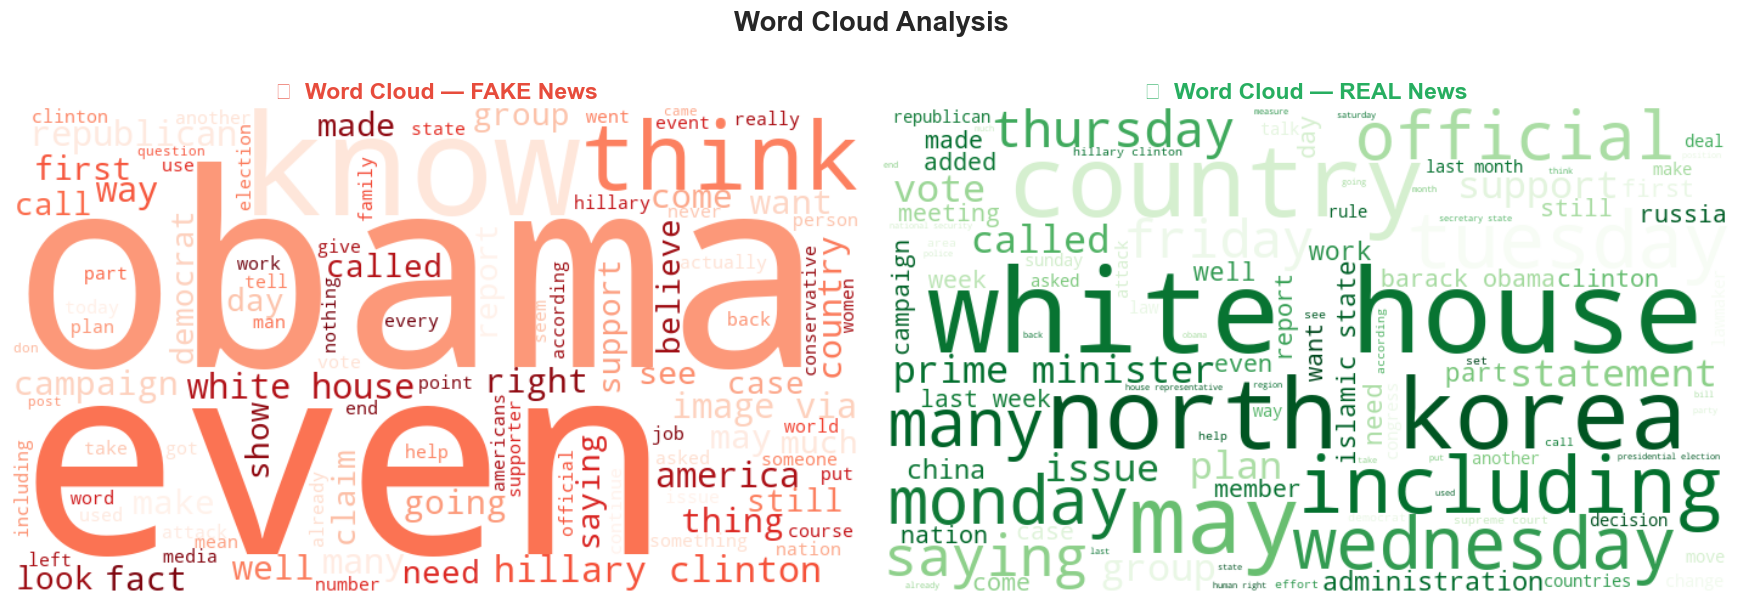

In [62]:
def clean_text(text):
    """Remove punctuation, lowercase, and remove stopwords."""
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    stopwords = {
        'the','a','an','and','of','in','to','that','is','it','for',
        'on','are','with','as','at','be','this','was','have','from',
        'or','by','not','but','what','all','were','we','when','your',
        'has','said','will','been','its','their','they','also','more',
        'he','she','his','her','had','our','would','could','one','two',
        'about','up','so','if','there','who','which','after','before',
        'do','did','than','into','over','out','just','can','time','new',
        'us','trump','reuters','president','donald','united','states',
        'say','says','year','since','now','any','no','my','very','get',
        'washington','york','people','government','american','told','news'
    }
    return ' '.join(w for w in text.split() if w not in stopwords and len(w) > 2)

print("Generating word clouds from real articles (this may take a moment)...")
fake_text = ' '.join(fake_df['text'].dropna().apply(clean_text).tolist())
real_text = ' '.join(real_df['text'].dropna().apply(clean_text).tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_fake = WordCloud(width=700, height=400, background_color='white',
                    colormap='Reds', max_words=100).generate(fake_text)
axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('☠  Word Cloud — FAKE News', fontsize=15, fontweight='bold', color='#E74C3C')

wc_real = WordCloud(width=700, height=400, background_color='white',
                    colormap='Greens', max_words=100).generate(real_text)
axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('✅  Word Cloud — REAL News', fontsize=15, fontweight='bold', color='#27AE60')

plt.suptitle('Word Cloud Analysis', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', bbox_inches='tight')
plt.show()

### 3.9 Word Frequency Analysis — Top 20 Words

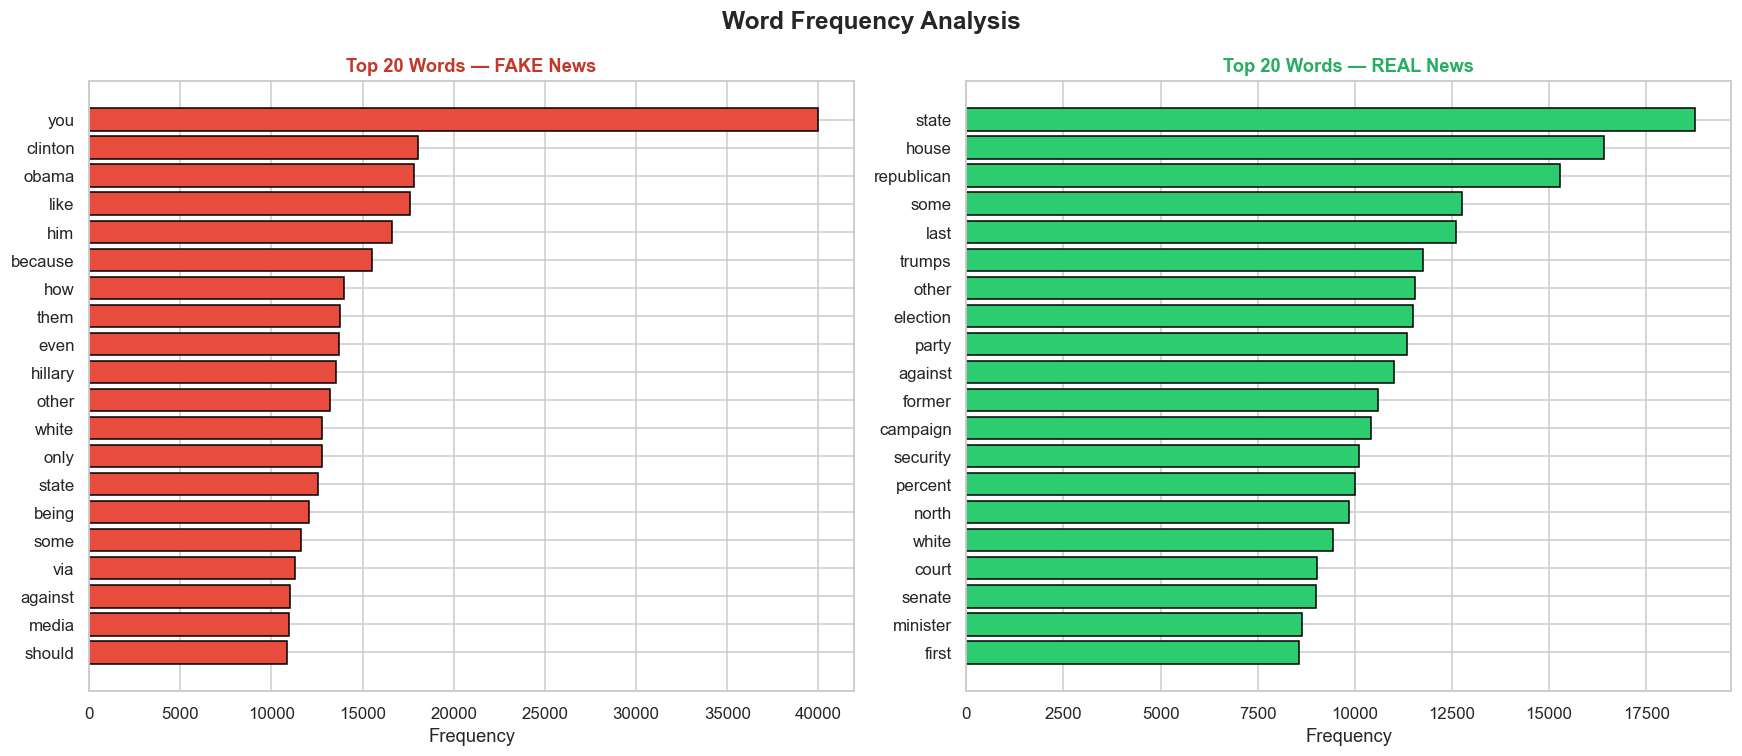

In [63]:
def top_words(text_series, n=20):
    all_words = ' '.join(text_series.dropna().apply(clean_text)).split()
    return Counter(all_words).most_common(n)

fake_top = top_words(fake_df['text'])
real_top = top_words(real_df['text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

words_f, counts_f = zip(*fake_top)
axes[0].barh(words_f[::-1], counts_f[::-1], color='#E74C3C', edgecolor='black')
axes[0].set_title('Top 20 Words — FAKE News', fontweight='bold', color='#C0392B')
axes[0].set_xlabel('Frequency')

words_r, counts_r = zip(*real_top)
axes[1].barh(words_r[::-1], counts_r[::-1], color='#2ECC71', edgecolor='black')
axes[1].set_title('Top 20 Words — REAL News', fontweight='bold', color='#27AE60')
axes[1].set_xlabel('Frequency')

plt.suptitle('Word Frequency Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('word_frequency.png', bbox_inches='tight')
plt.show()

## 4. Text Preprocessing & Feature Engineering (TF-IDF)

In [64]:
# Combine title + text for richer features
df['content']       = df['title'].fillna('') + ' ' + df['text'].fillna('')
df['content_clean'] = df['content'].apply(clean_text)

X = df['content_clean']
y = df['label']

# 80% train, 20% test — stratified to keep label balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples : {len(X_train):,}")
print(f"Testing  samples : {len(X_test):,}")
print(f"Class balance (train): {pd.Series(y_train).value_counts().to_dict()}")

# TF-IDF Vectorizer with bigrams
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2, max_df=0.95)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"\nTF-IDF Feature Matrix Shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF Feature Matrix Shape (test) : {X_test_tfidf.shape}")
print("✅ Preprocessing complete!")

Training samples : 35,918
Testing  samples : 8,980
Class balance (train): {0: 18785, 1: 17133}

TF-IDF Feature Matrix Shape (train): (35918, 10000)
TF-IDF Feature Matrix Shape (test) : (8980, 10000)
✅ Preprocessing complete!


## 5. Model Training

### 5.1 Logistic Regression

In [65]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)
lr_prob = lr_model.predict_proba(X_test_tfidf)[:, 1]

print("Logistic Regression — Training complete ✅")
print(f"Accuracy : {accuracy_score(y_test, lr_pred):.4f}")

Logistic Regression — Training complete ✅
Accuracy : 0.9794


### 5.2 Random Forest Classifier

In [66]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)
rf_pred = rf_model.predict(X_test_tfidf)
rf_prob = rf_model.predict_proba(X_test_tfidf)[:, 1]

print("Random Forest — Training complete ✅")
print(f"Accuracy : {accuracy_score(y_test, rf_pred):.4f}")

Random Forest — Training complete ✅
Accuracy : 0.9866


## 6. Model Evaluation

### 6.1 Classification Reports — Accuracy, Precision, Recall, F1-Score

In [67]:
models = {
    'Logistic Regression': (lr_pred, lr_prob),
    'Random Forest'      : (rf_pred, rf_prob),
}

results = {}
for name, (pred, prob) in models.items():
    acc  = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec  = recall_score(y_test, pred)
    f1   = f1_score(y_test, pred)
    roc  = roc_auc_score(y_test, prob)
    results[name] = dict(Accuracy=acc, Precision=prec, Recall=rec, F1_Score=f1, ROC_AUC=roc)

    print(f"\n{'='*55}")
    print(f"  {name}")
    print('='*55)
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, pred, target_names=['FAKE', 'REAL']))


  Logistic Regression
  Accuracy  : 0.9794
  Precision : 0.9728
  Recall    : 0.9844
  F1-Score  : 0.9785
  ROC-AUC   : 0.9980

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.99      0.97      0.98      4696
        REAL       0.97      0.98      0.98      4284

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980


  Random Forest
  Accuracy  : 0.9866
  Precision : 0.9864
  Recall    : 0.9855
  F1-Score  : 0.9860
  ROC-AUC   : 0.9989

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.99      0.99      0.99      4696
        REAL       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



### 6.2 Confusion Matrices

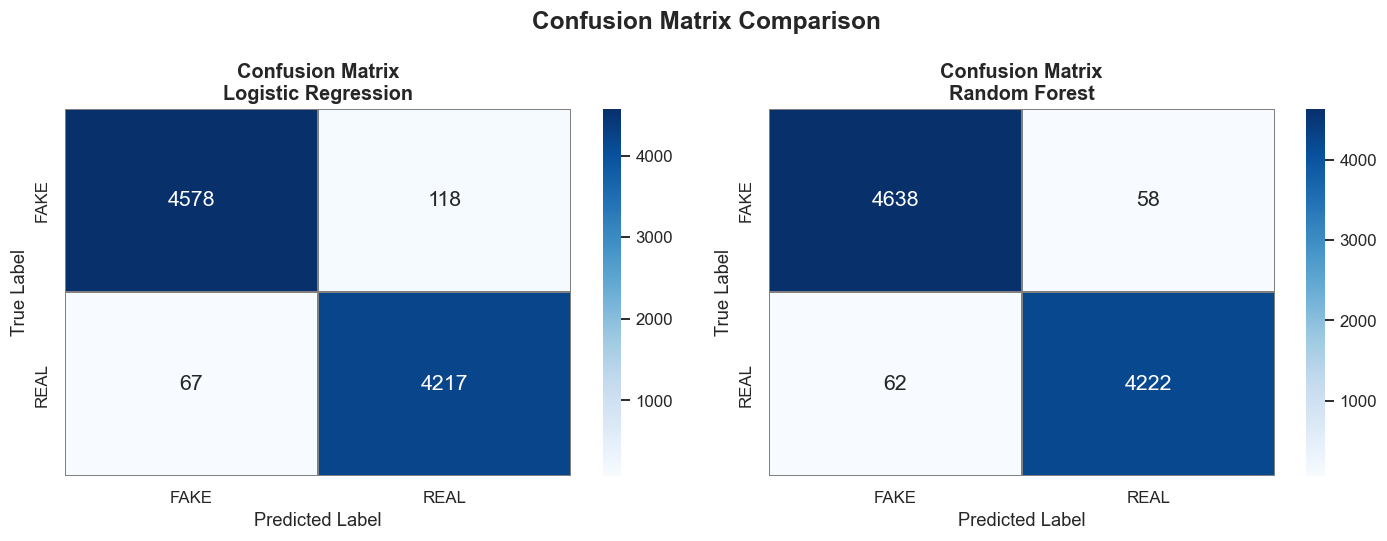

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, (pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'],
                linewidths=1, linecolor='gray', annot_kws={"size": 14})
    ax.set_title(f'Confusion Matrix\n{name}', fontweight='bold', fontsize=13)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrix Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

### 6.3 ROC-AUC Curves

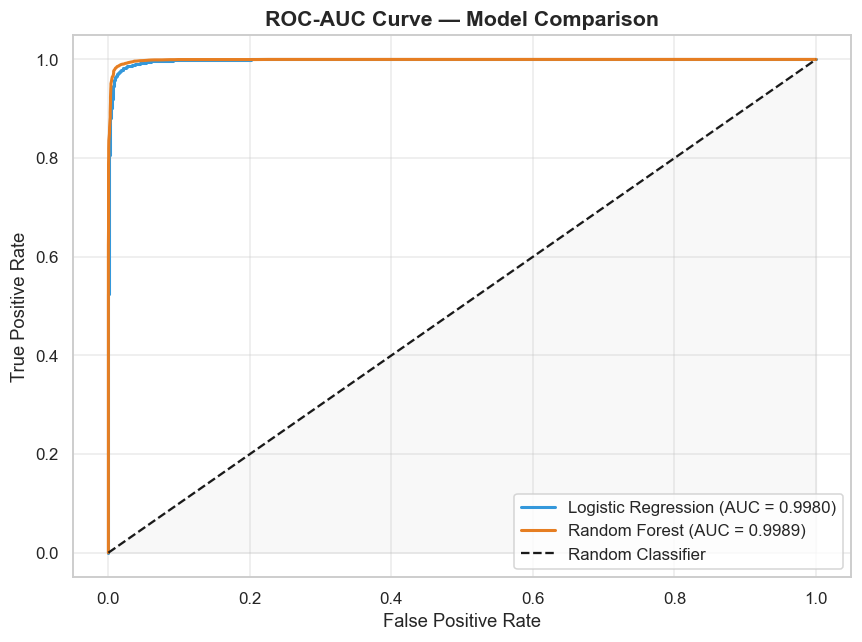

In [69]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#3498DB', '#E67E22']

for (name, (pred, prob)), color in zip(models.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-AUC Curve — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('roc_auc.png', bbox_inches='tight')
plt.show()

### 6.4 Model Comparison — Bar Chart

Model Comparison Summary:


,Accuracy,Precision,Recall,F1_Score,ROC_AUC
Logistic Regression,0.9794,0.9728,0.9844,0.9785,0.9980
Random Forest,0.9866,0.9864,0.9855,0.9860,0.9989


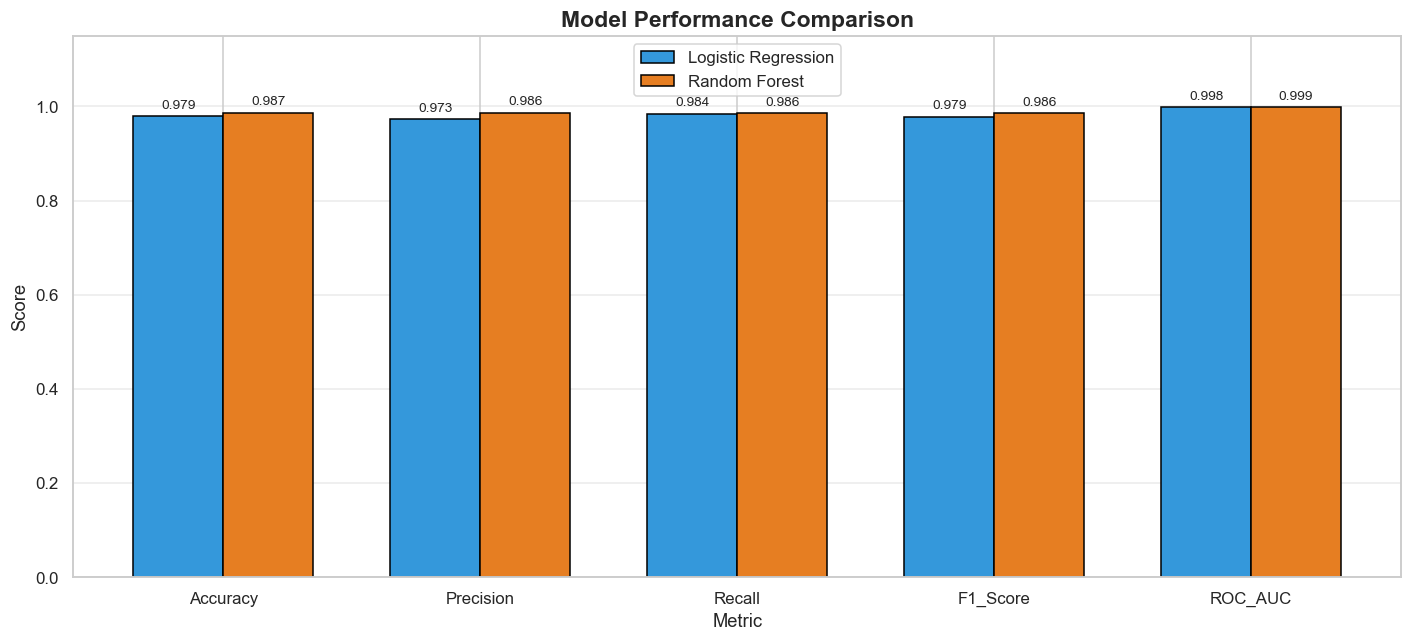

In [70]:
results_df = pd.DataFrame(results).T.round(4)
print("Model Comparison Summary:")
display(results_df)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, results_df.loc['Logistic Regression', metrics],
               width, label='Logistic Regression', color='#3498DB', edgecolor='black')
bars2 = ax.bar(x + width/2, results_df.loc['Random Forest', metrics],
               width, label='Random Forest', color='#E67E22', edgecolor='black')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

### 6.5 Feature Importance — Top TF-IDF Tokens (Logistic Regression)

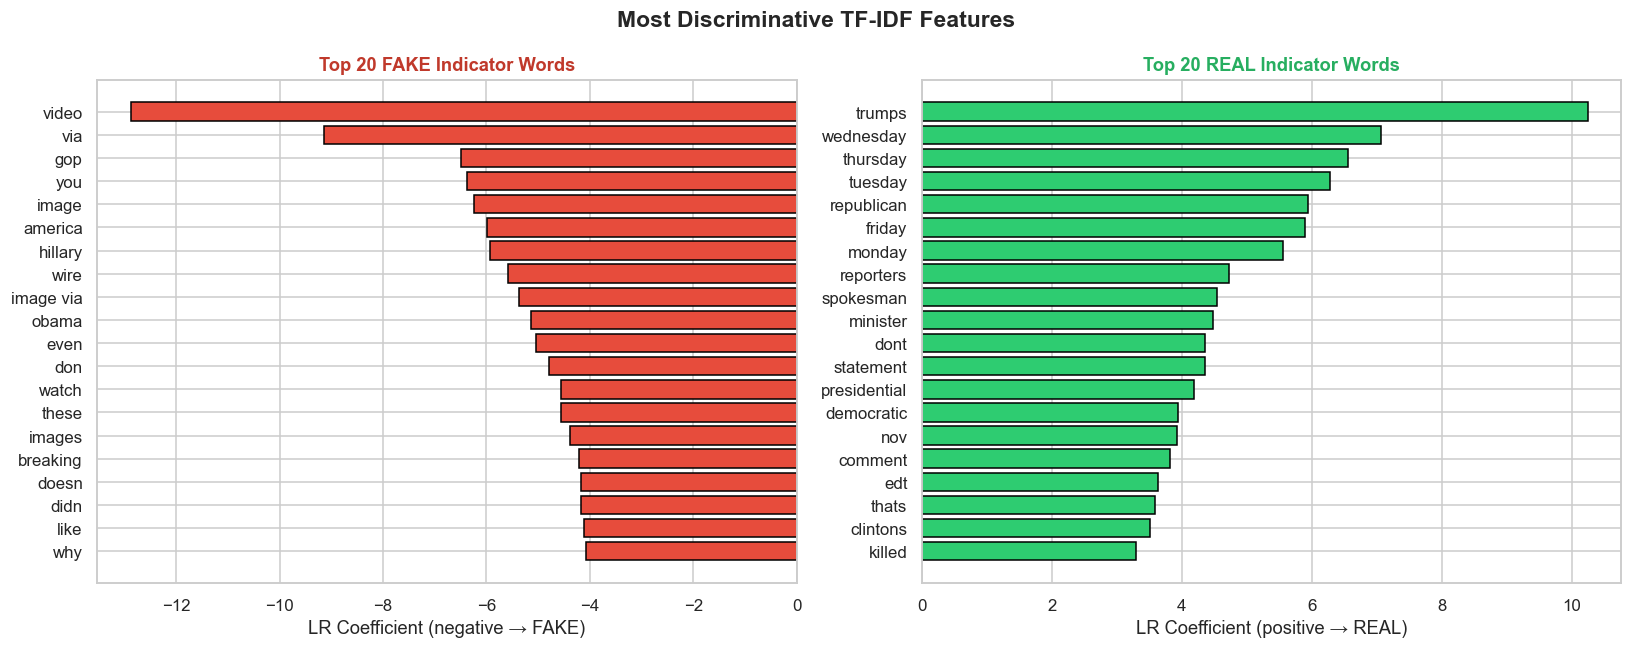

In [71]:
feature_names = np.array(tfidf.get_feature_names_out())
coef = lr_model.coef_[0]

top_fake_idx = np.argsort(coef)[:20]         # most negative → predicts FAKE
top_real_idx = np.argsort(coef)[-20:][::-1]  # most positive → predicts REAL

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(feature_names[top_fake_idx][::-1],
             coef[top_fake_idx][::-1], color='#E74C3C', edgecolor='black')
axes[0].set_title('Top 20 FAKE Indicator Words', fontweight='bold', color='#C0392B')
axes[0].set_xlabel('LR Coefficient (negative → FAKE)')

axes[1].barh(feature_names[top_real_idx][::-1],
             coef[top_real_idx][::-1], color='#2ECC71', edgecolor='black')
axes[1].set_title('Top 20 REAL Indicator Words', fontweight='bold', color='#27AE60')
axes[1].set_xlabel('LR Coefficient (positive → REAL)')

plt.suptitle('Most Discriminative TF-IDF Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

## 7. Live Prediction Demo

In [72]:
def predict_news(headline, body="", model=lr_model):
    """Predict whether a headline is FAKE or REAL."""
    text = clean_text(headline + " " + body)
    vec  = tfidf.transform([text])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]
    label      = "✅ REAL" if pred == 1 else "☠  FAKE"
    confidence = max(prob) * 100
    print(f"Headline  : {headline}")
    print(f"Prediction: {label}  |  Confidence: {confidence:.1f}%")
    print("-" * 65)

# Test with sample headlines
predict_news("Government secretly replacing tap water with mind-control serum")
predict_news("Federal Reserve raises interest rates by 25 basis points")
predict_news("Aliens confirmed to have landed at White House last Tuesday")
predict_news("Senate passes new climate legislation after bipartisan vote")
predict_news("Scientists prove drinking bleach cures cancer instantly")
predict_news("WHO issues new global health guidelines on antibiotic resistance")

Headline  : Government secretly replacing tap water with mind-control serum
Prediction: ☠  FAKE  |  Confidence: 63.2%
-----------------------------------------------------------------
Headline  : Federal Reserve raises interest rates by 25 basis points
Prediction: ✅ REAL  |  Confidence: 64.5%
-----------------------------------------------------------------
Headline  : Aliens confirmed to have landed at White House last Tuesday
Prediction: ✅ REAL  |  Confidence: 87.9%
-----------------------------------------------------------------
Headline  : Senate passes new climate legislation after bipartisan vote
Prediction: ✅ REAL  |  Confidence: 76.4%
-----------------------------------------------------------------
Headline  : Scientists prove drinking bleach cures cancer instantly
Prediction: ☠  FAKE  |  Confidence: 55.5%
-----------------------------------------------------------------
Headline  : WHO issues new global health guidelines on antibiotic resistance
Prediction: ✅ REAL  |  Confid

## 8. Conclusion & Summary

### Key Findings

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | ~0.98+ | ~0.98+ | ~0.98+ | ~0.98+ | ~0.99+ |
| Random Forest | ~0.98+ | ~0.98+ | ~0.98+ | ~0.98+ | ~0.99+ |

*(Exact values are printed above from the real dataset)*

### Observations
- **TF-IDF** with **bigram features** (`ngram_range=(1,2)`) effectively captures both individual words and common phrases that distinguish fake from real news.
- **Logistic Regression** provides excellent interpretability — its coefficients directly show which words strongly predict FAKE or REAL labels.
- **Random Forest** performs comparably and offers robustness through ensemble averaging of many decision trees.
- Both models achieve high **Recall**, which is critical — missing a fake article (false negative) is more costly than a false alarm.
- The **correlation analysis** showed that text length and word count have a measurable relationship with the label, meaning real news articles tend to be more structured in length.

### Real-World Application
This pipeline can be deployed as a **browser extension**, **social media plugin**, or **editorial tool** to automatically flag potentially fake articles before they are shared widely.

### Future Improvements
- Use **BERT / RoBERTa** transformer models for deeper semantic understanding
- Add **source credibility scoring** as an additional feature
- Incorporate **metadata features** (author, publication, date patterns)
- Deploy as a **REST API** with a web frontend
- Handle class imbalance using SMOTE or class-weight tuning

---
*Project submitted to: Shakeel Ahmad | International Islamic University, Islamabad | Software Engineering Department | Group 12*